EARTHQUAKE DATA ANALYSIS AND PREDICTION PROJECT
EARTHQUAKE DATA ANALYSIS SYSTEM - MULTI-MODEL COMPARISON

Step 1: Loading and preprocessing data...
--------------------------------------------------------------------------------
Original data shape: (1339, 5)
Cleaned data shape: (1339, 12)

Data Quality Report:
Valid longitude: 1339/1339
Valid latitude: 1339/1339
Valid depth: 1311/1339
Valid magnitude: 1339/1339


Step 2: Feature engineering...
--------------------------------------------------------------------------------
Processed data shape: (1308, 75)
Number of features: 75
Time range: 2023-07-02 18:27:41 to 2025-12-09 06:38:31


Step 3: Exploratory data analysis...
--------------------------------------------------------------------------------
EXPLORATORY DATA ANALYSIS


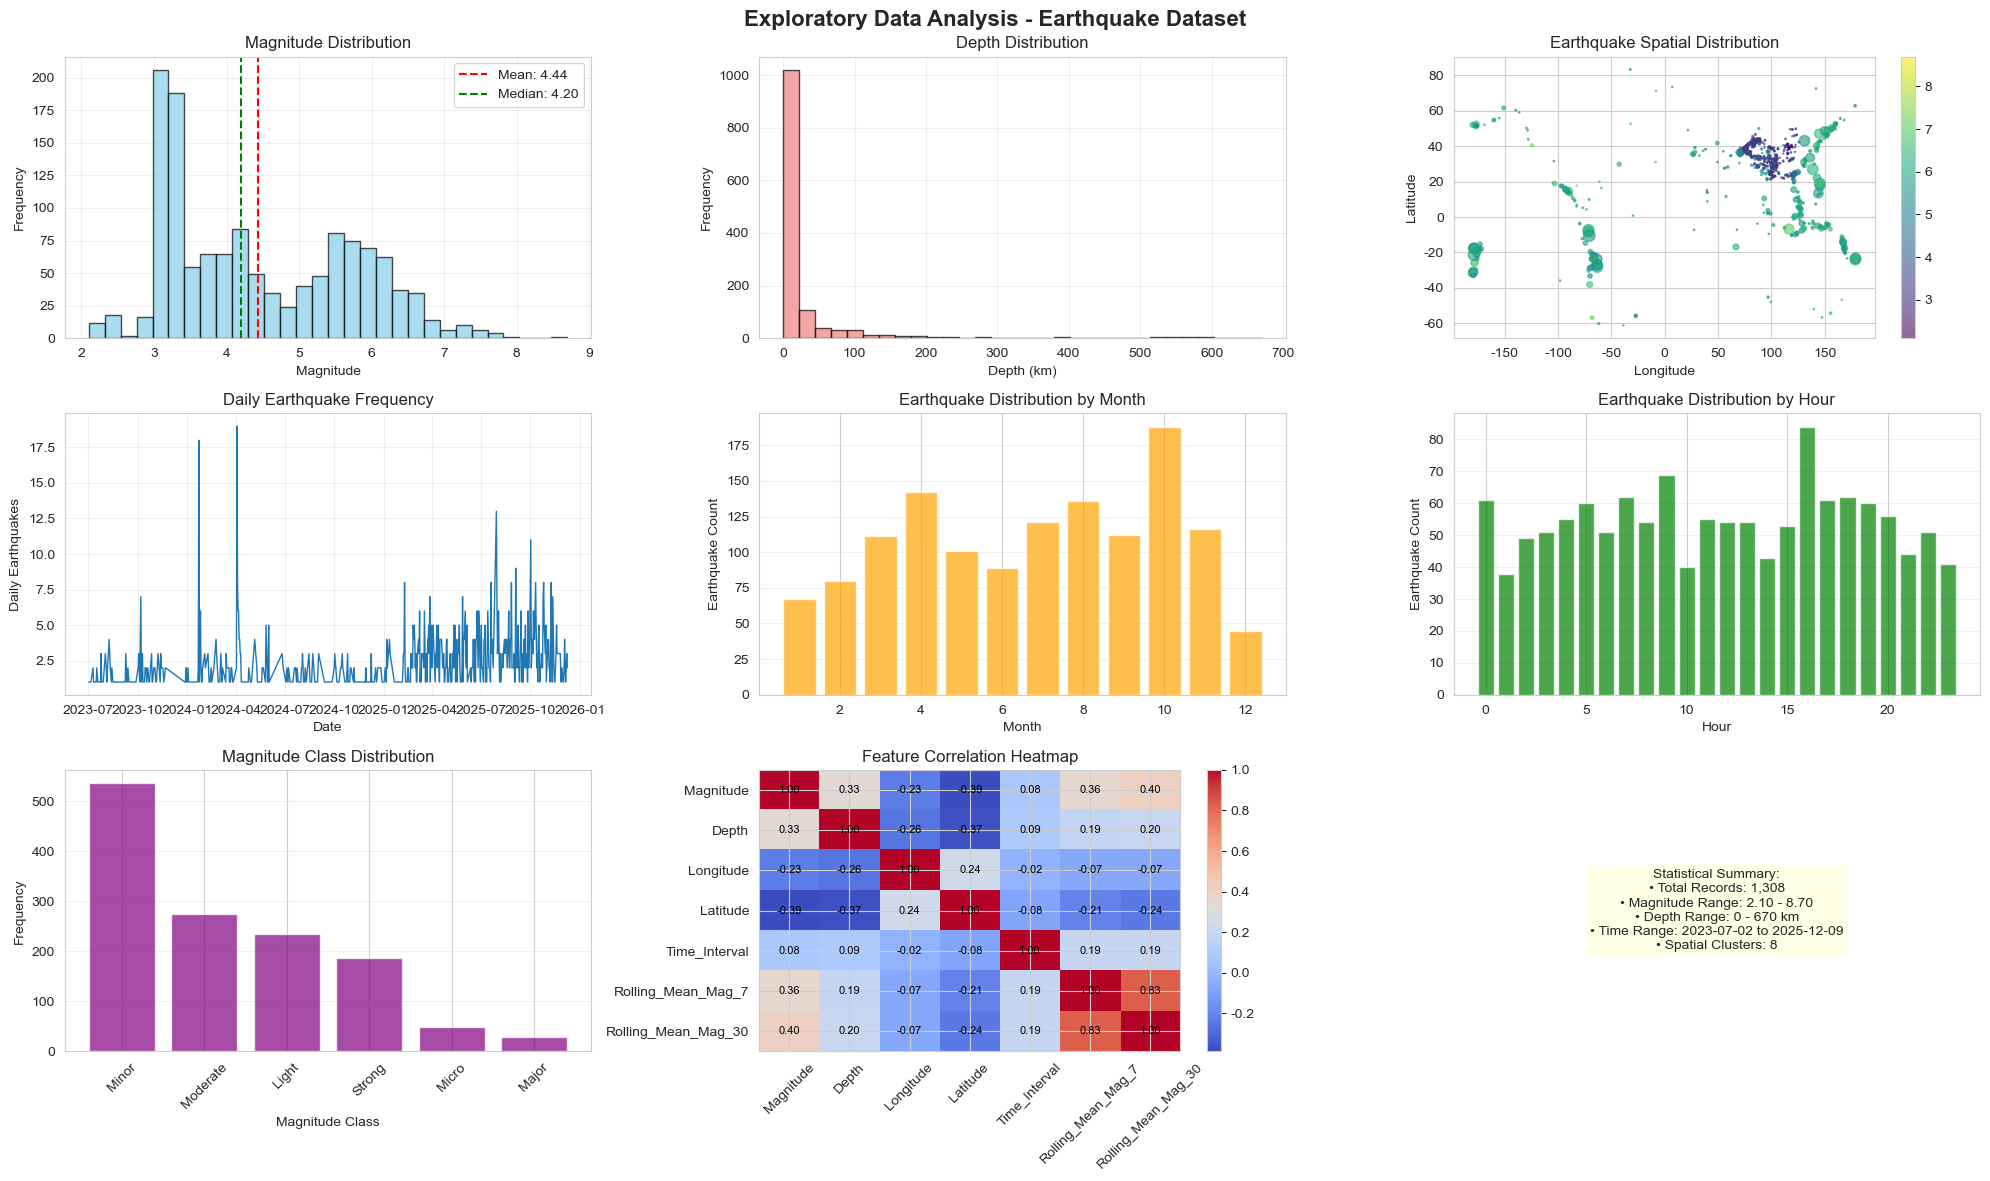



Step 4: Classification models comparison...
--------------------------------------------------------------------------------
Classification features: 50
Target distribution: 43.96% positive (575/1308)
CLASSIFICATION MODEL COMPARISON - Predicting Is_Major
Target distribution: 43.96% positive (575/1308)
Baseline accuracy (always predict majority class): 56.04%

Training Logistic Regression...
  Average F1: 0.5269 (±0.1326)
  Average AUC: 0.6830
  Average Accuracy: 0.6881 (±0.1101)
  Average Precision: 0.6308
  Average Recall: 0.5065
  Hyperparameter tuning...
  Best params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1}
  Best CV score: 0.5821
  Final CV F1: 0.5821 (±0.0769)
  Final CV AUC: 0.6969 (±0.0948)
  Final CV Accuracy: 0.7330 (±0.1047)

Training Random Forest...
  Average F1: 0.6607 (±0.0755)
  Average AUC: 0.7444
  Average Accuracy: 0.7064 (±0.1381)
  Average Precision: 0.6543
  Average Recall: 0.7413
  Hyperparameter tuning...
  Best params: {'n_estimators': 200, 'min_sa

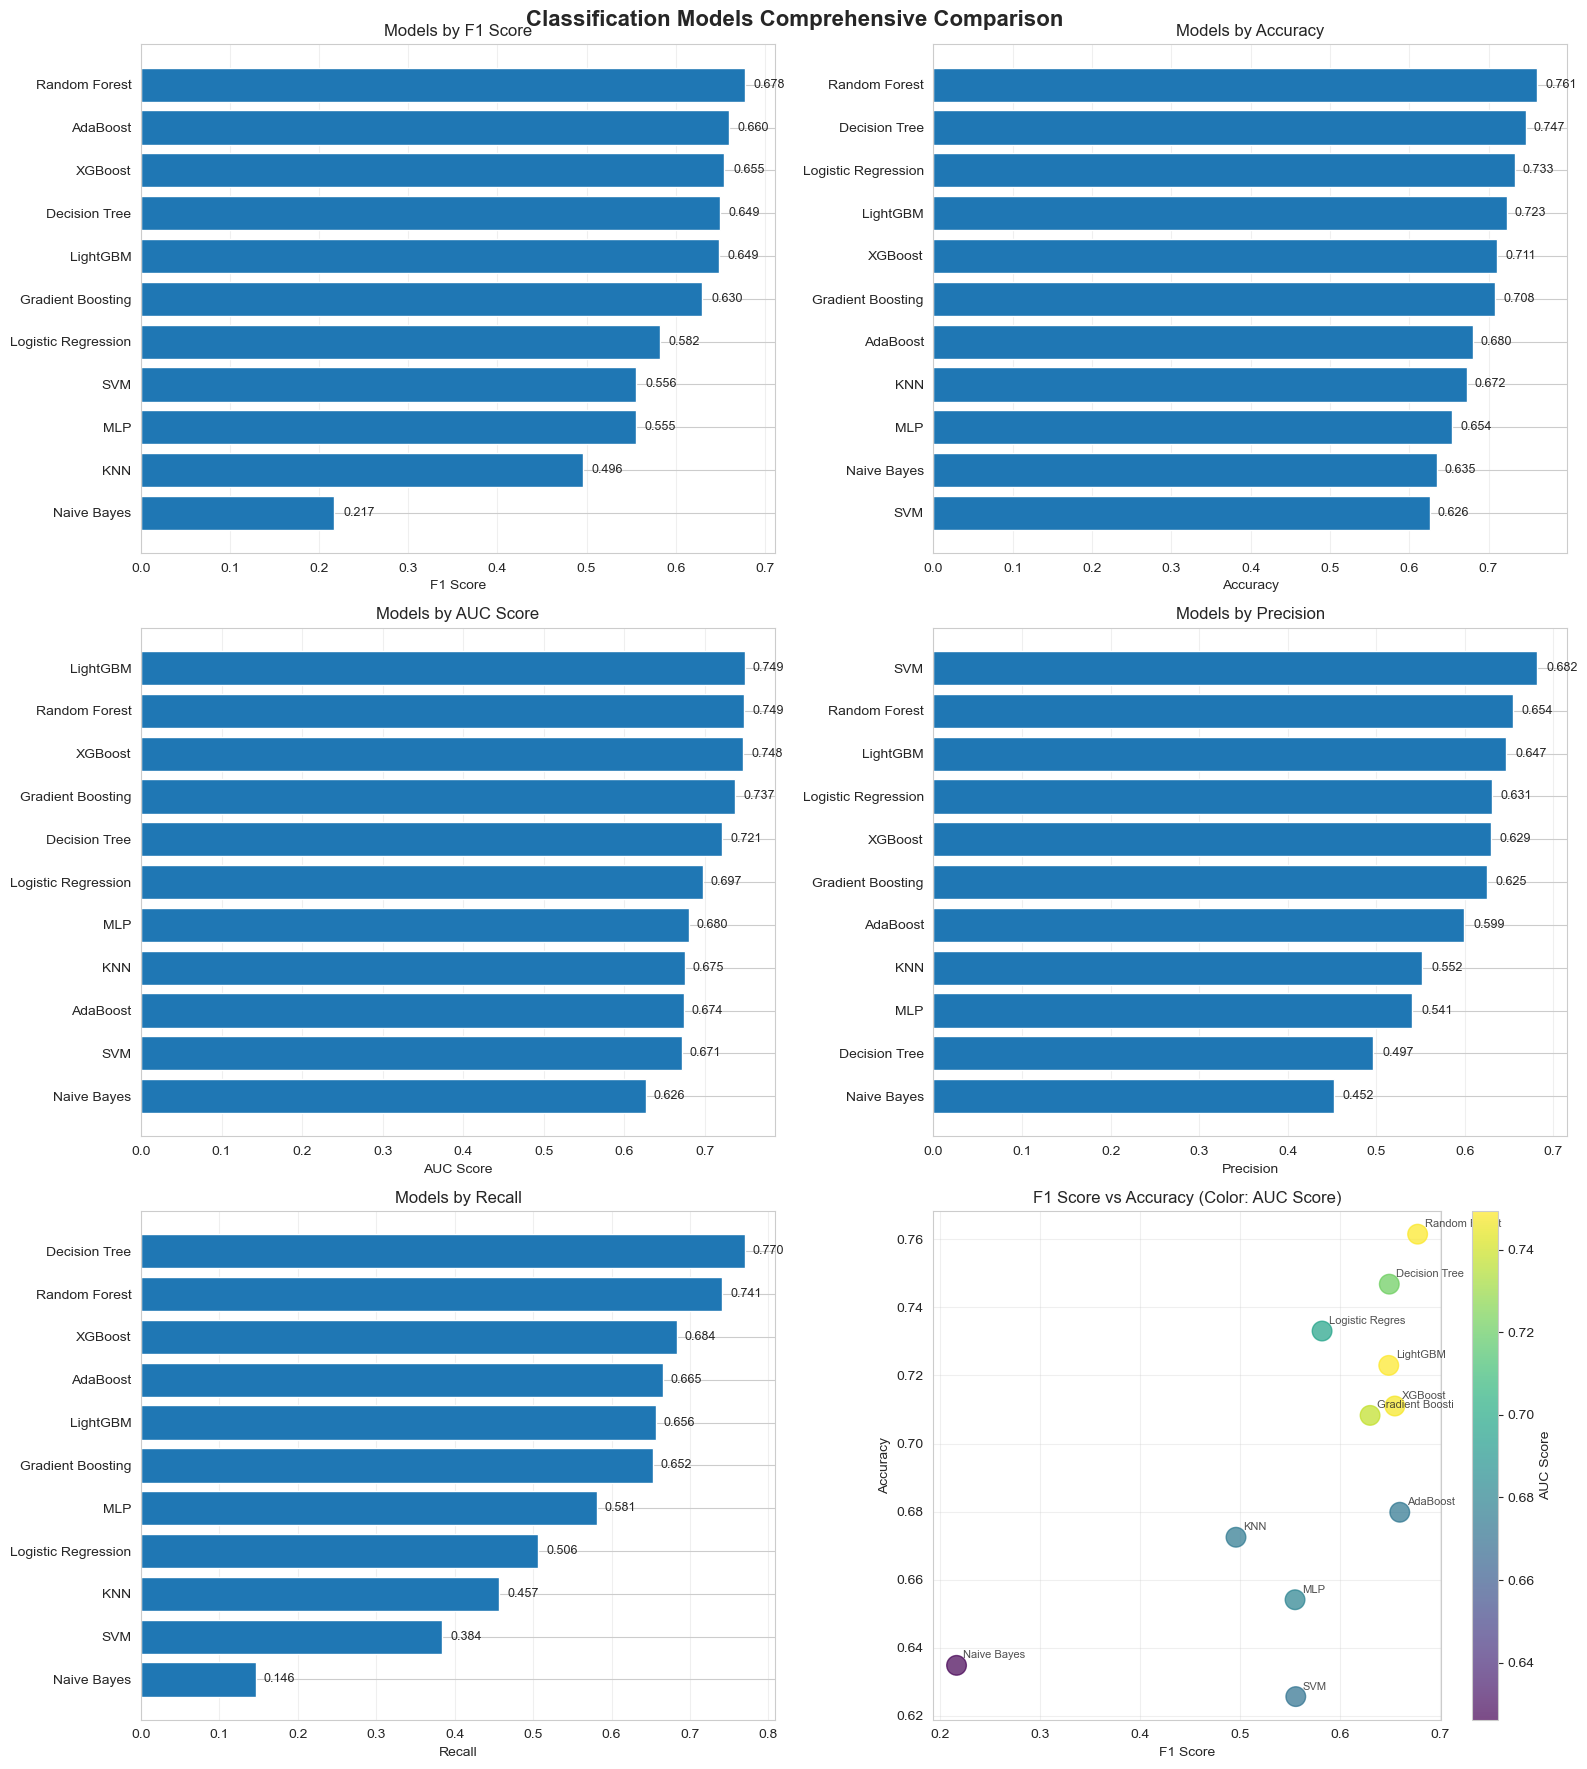



Generating detailed model comparison radar chart...


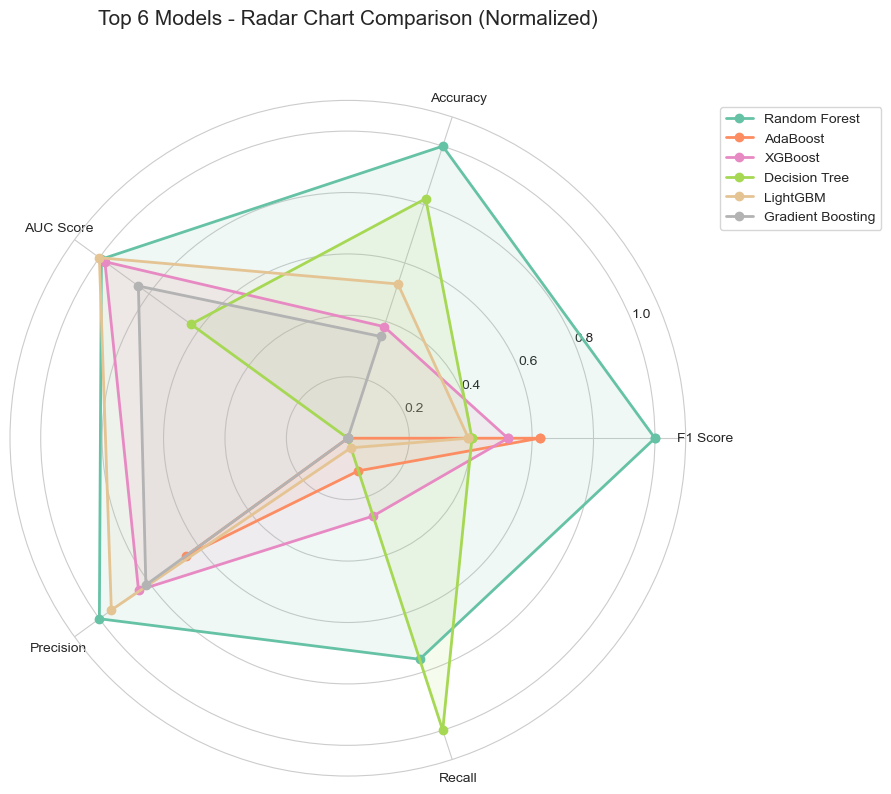



Step 5: Regression models comparison...
--------------------------------------------------------------------------------
Regression features: 53
Target statistics: Mean=4.44, Range=2.10-8.70
REGRESSION MODEL COMPARISON - Predicting Magnitude

Training Linear Regression...
  Average R²: -0.0055 (±0.4258)
  Average MAE: 0.9124 (±0.0787)
  Final CV R²: -0.0055 (±0.4258)
  Final CV MAE: 0.7084 (±0.0611)

Training Ridge Regression...
  Average R²: 0.0780 (±0.3046)
  Average MAE: 0.9043 (±0.0776)
  Hyperparameter tuning...
  Best params: {'alpha': 100}
  Best CV score: 0.2701
  Final CV R²: 0.2701 (±0.0863)
  Final CV MAE: 0.6863 (±0.0571)

Training Lasso Regression...
  Average R²: -0.2839 (±0.1636)
  Average MAE: 1.2509 (±0.0899)
  Hyperparameter tuning...
  Best params: {'alpha': 0.01}
  Best CV score: 0.2799
  Final CV R²: 0.2799 (±0.1093)
  Final CV MAE: 0.6748 (±0.0614)

Training ElasticNet...
  Average R²: -0.2839 (±0.1636)
  Average MAE: 1.2508 (±0.0899)
  Hyperparameter tuning...


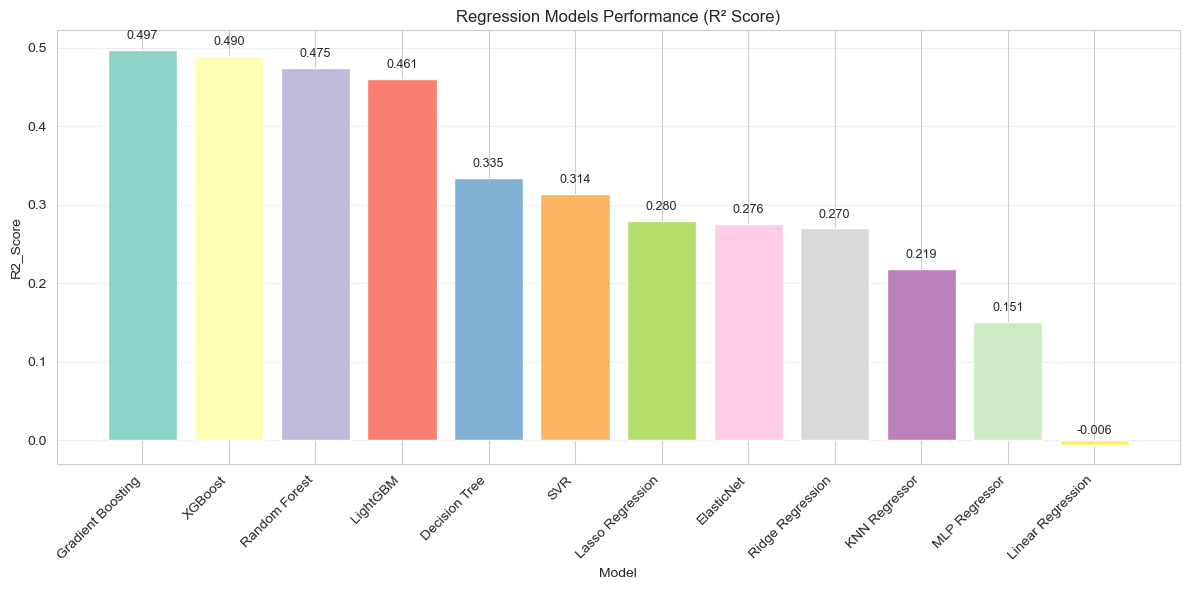

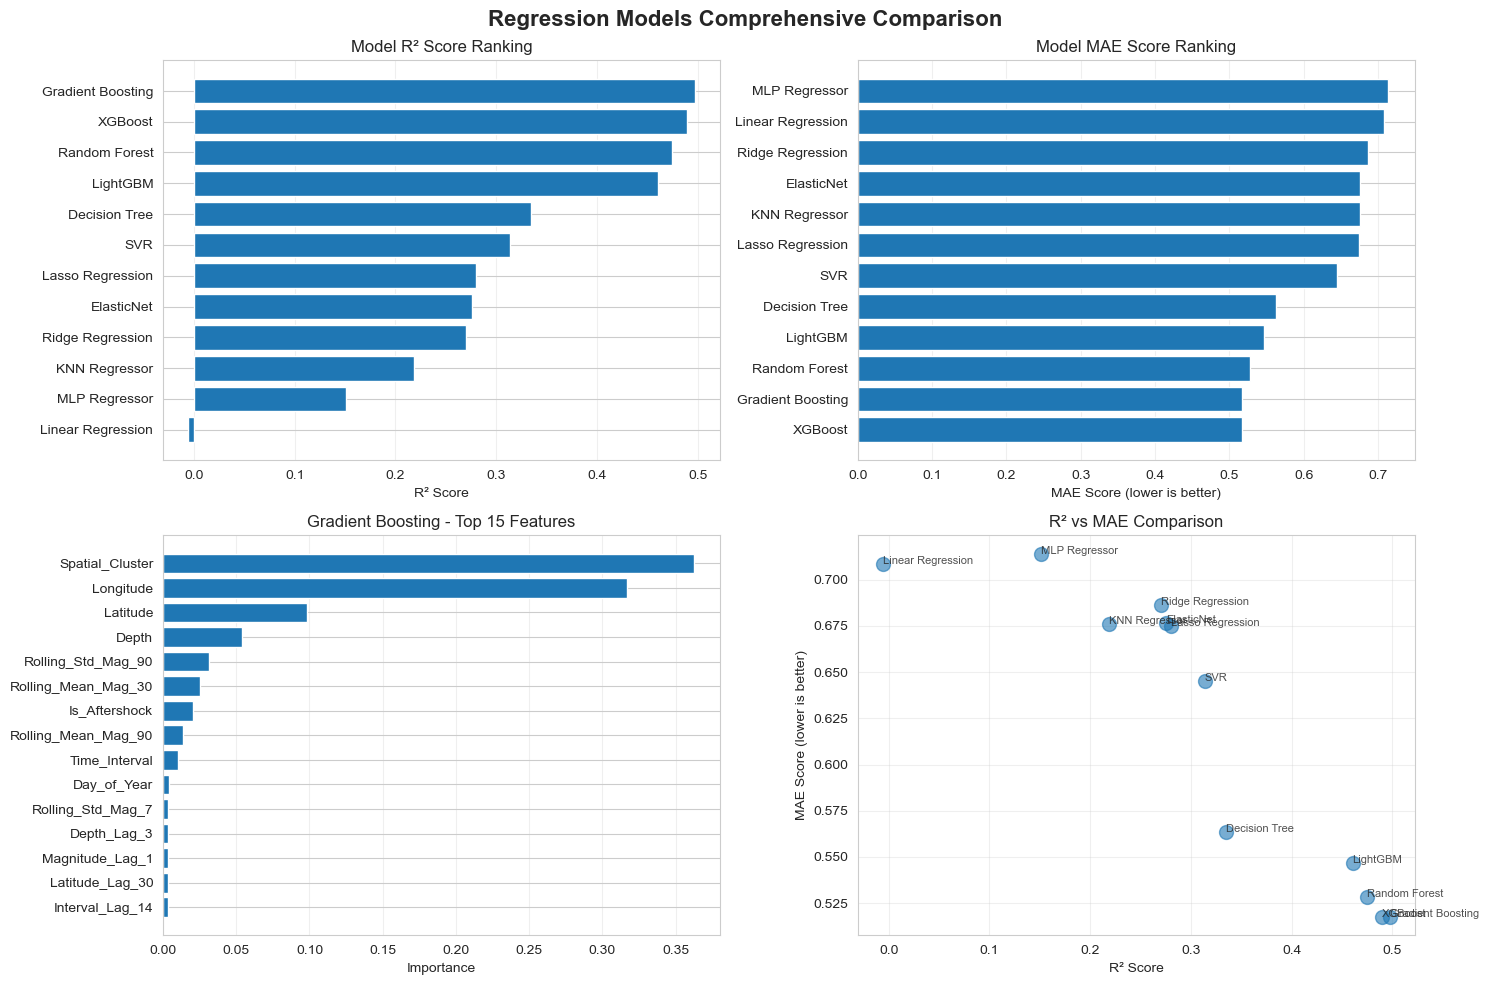



Step 6: Spatial clustering analysis...
--------------------------------------------------------------------------------
SPATIAL CLUSTERING ANALYSIS

1. DBSCAN Clustering...

2. KMeans Clustering...

CLUSTERING ALGORITHM PERFORMANCE COMPARISON
        n_clusters  n_noise  silhouette     dbi    inertia
DBSCAN         5.0     66.0      0.7301  0.2271        NaN
KMeans         2.0      NaN      0.7376  0.6666  1331.0715


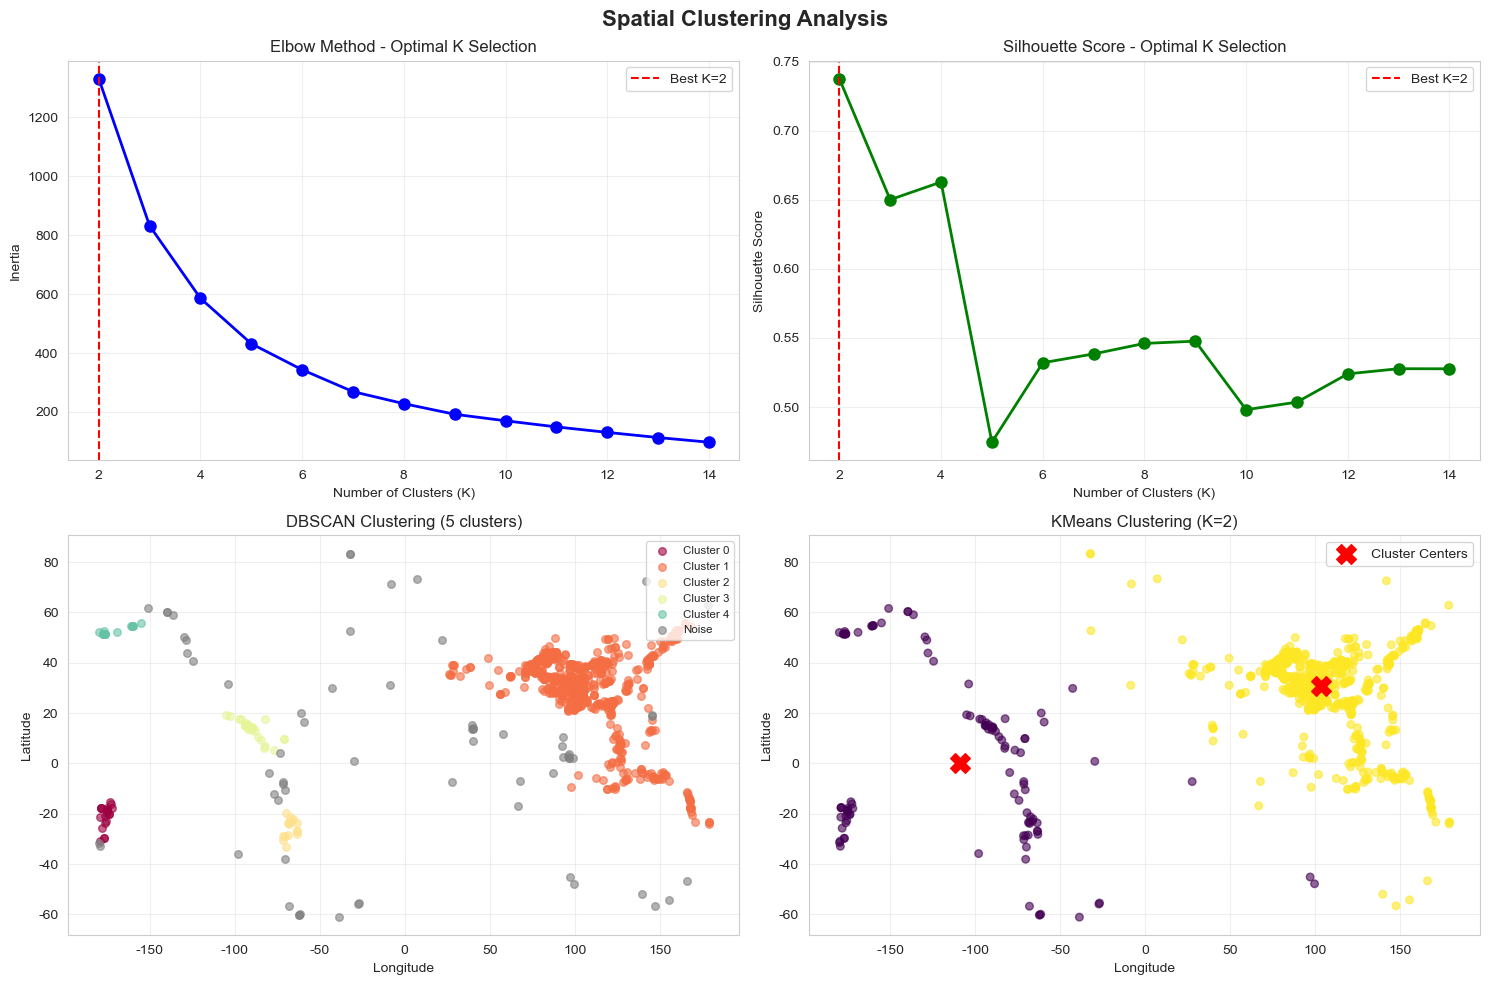



Step 7: Comprehensive summary...
--------------------------------------------------------------------------------

BEST MODELS SUMMARY

Best Classification Model: Random Forest
  F1 Score: 0.6776
  AUC Score: 0.7487

Best Regression Model: Gradient Boosting
  R² Score: 0.4973
  MAE Score: 0.5178


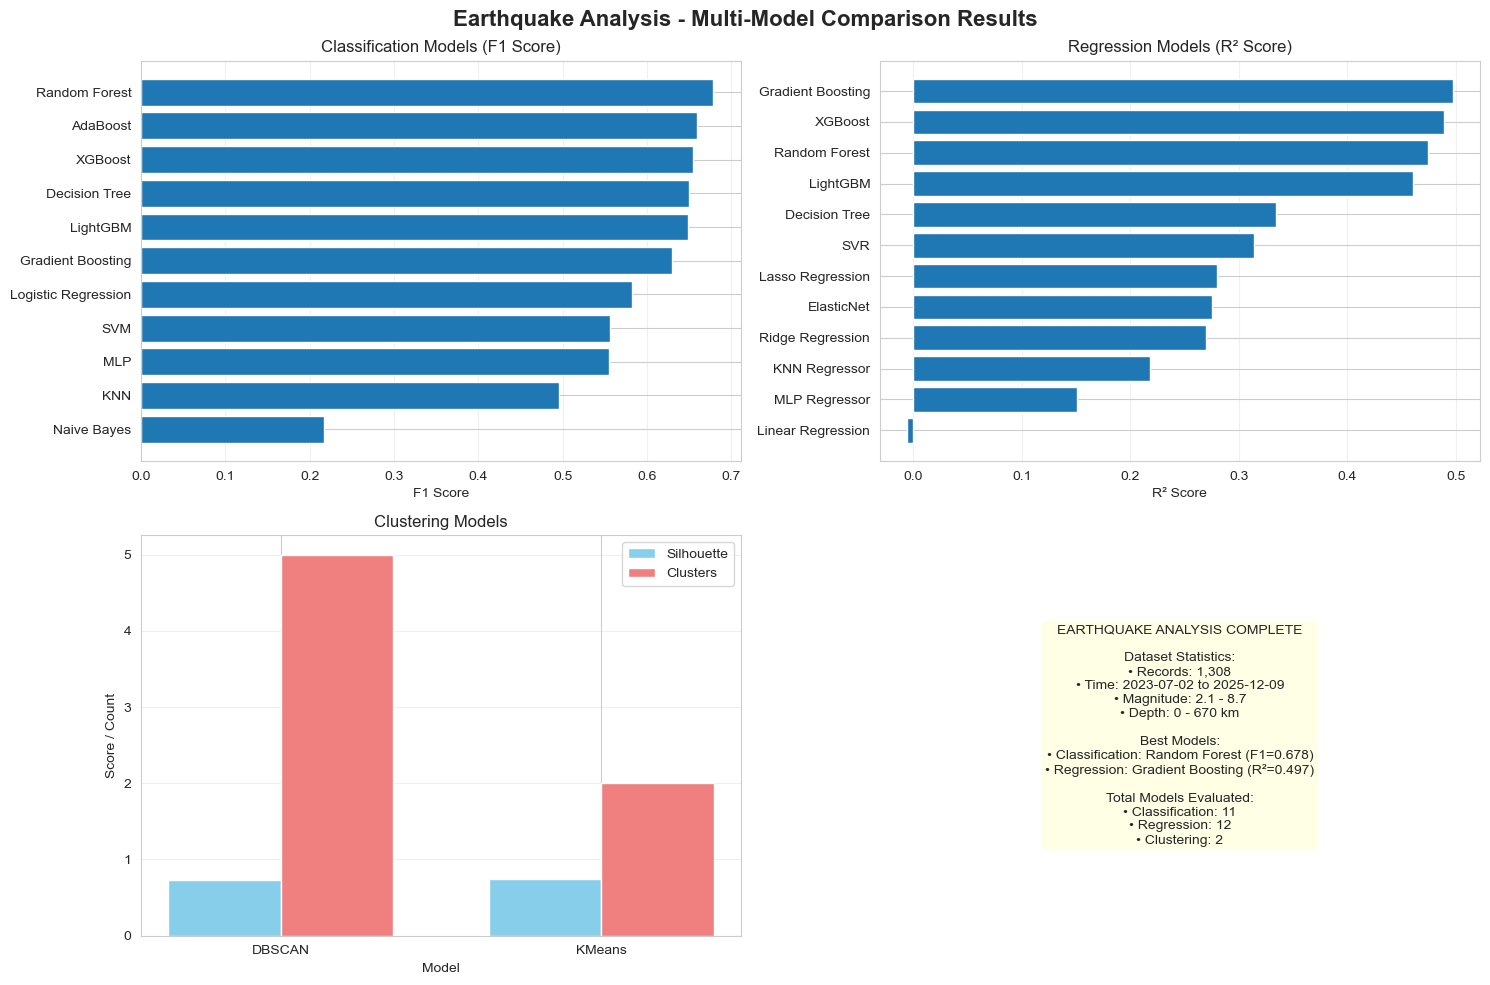


Results saved to: earthquake_analysis_results_20251213_024324.csv

ANALYSIS COMPLETE SUCCESSFULLY!


In [1]:
# basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# machine learning libraries
from sklearn.model_selection import TimeSeriesSplit, train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier, MLPRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA

# perfomance evaluation libraries
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score, davies_bouldin_score
)

# set global plot styles
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [14, 8]

print("="*80)
print("EARTHQUAKE DATA ANALYSIS AND PREDICTION PROJECT")
print("="*80)

# ==================== 2. data processor ====================
class DataProcessor:
    
    @staticmethod
    def clean_earthquake_data(df):
        """clean earthquake data"""
        df_clean = df.copy()
        
        # exchange time colume
        df_clean['Time'] = pd.to_datetime(df_clean['时间'], format='%Y-%m-%d %H:%M:%S')
        
        # split longitude and latitude
        df_clean['Coordinates'] = df_clean['经纬度'].str.replace('°', '')
        coords_split = df_clean['Coordinates'].str.split(' ', expand=True)
        df_clean['Longitude'] = pd.to_numeric(coords_split[0], errors='coerce')
        df_clean['Latitude'] = pd.to_numeric(coords_split[1], errors='coerce')
        
        # clean depth and magnitude
        df_clean['Depth'] = df_clean['震源深度'].str.replace('千米', '').astype(float)
        df_clean['Magnitude'] = df_clean['级数'].str.replace('级', '').astype(float)
        
        # delete origin columns
        df_clean = df_clean.drop(columns=['时间', '经纬度', '震源深度', '级数', 'Coordinates'])
        df_clean = df_clean[['Time', 'Longitude', 'Latitude', 'Depth', 'Magnitude']]
        
        # check validation
        df_clean['Longitude_Valid'] = (df_clean['Longitude'] >= -180) & (df_clean['Longitude'] <= 180)
        df_clean['Latitude_Valid'] = (df_clean['Latitude'] >= -90) & (df_clean['Latitude'] <= 90)
        df_clean['Depth_Valid'] = df_clean['Depth'] > 0
        df_clean['Magnitude_Valid'] = (df_clean['Magnitude'] >= 0) & (df_clean['Magnitude'] <= 10)
        
        # classify magnitude
        df_clean['Magnitude_Class'] = df_clean['Magnitude'].apply(DataProcessor.classify_magnitude)
        
        # add date and hour
        df_clean['Date'] = df_clean['Time'].dt.date
        df_clean['Hour'] = df_clean['Time'].dt.hour
        
        return df_clean
    
    @staticmethod
    def classify_magnitude(mag):
        """magnitude classify"""
        if mag < 3.0:
            return 'Micro'
        elif mag < 4.0:
            return 'Minor'
        elif mag < 5.0:
            return 'Light'
        elif mag < 6.0:
            return 'Moderate'
        elif mag < 7.0:
            return 'Strong'
        else:
            return 'Major'
    
    @staticmethod
    def load_and_engineer_features_fixed(df_clean):
        """load and engineer features"""
        df = df_clean.copy()
        
        if not pd.api.types.is_datetime64_any_dtype(df['Time']):
            df['Time'] = pd.to_datetime(df['Time'])
        
        df = df.sort_values('Time').reset_index(drop=True)
        
        # basic time features
        df['Year'] = df['Time'].dt.year
        df['Month'] = df['Time'].dt.month
        df['Weekday'] = df['Time'].dt.dayofweek
        df['Hour'] = df['Time'].dt.hour
        df['Day'] = df['Time'].dt.day
        df['Quarter'] = df['Time'].dt.quarter
        df['Day_of_Year'] = df['Time'].dt.dayofyear
        
        # season features
        def get_season(month):
            if month in [12, 1, 2]:
                return 'Winter'
            elif month in [3, 4, 5]:
                return 'Spring'
            elif month in [6, 7, 8]:
                return 'Summer'
            else:
                return 'Autumn'
        
        df['Season'] = df['Month'].apply(get_season)
        
        # time interval
        df['Time_Interval'] = df['Time'].diff().dt.total_seconds() / 3600
        
        # lag features
        for lag in [1, 2, 3, 7, 14, 30]:
            df[f'Magnitude_Lag_{lag}'] = df['Magnitude'].shift(lag)
            df[f'Depth_Lag_{lag}'] = df['Depth'].shift(lag)
            df[f'Longitude_Lag_{lag}'] = df['Longitude'].shift(lag)
            df[f'Latitude_Lag_{lag}'] = df['Latitude'].shift(lag)
            df[f'Interval_Lag_{lag}'] = df['Time_Interval'].shift(lag)
        
        # rolling features
        window_sizes = [7, 14, 30, 90]
        for window in window_sizes:
            df[f'Rolling_Mean_Mag_{window}'] = df['Magnitude'].shift(1).rolling(window=window, min_periods=1).mean()
            df[f'Rolling_Std_Mag_{window}'] = df['Magnitude'].shift(1).rolling(window=window, min_periods=1).std()
            df[f'Rolling_Max_Mag_{window}'] = df['Magnitude'].shift(1).rolling(window=window, min_periods=1).max()
            df[f'Rolling_Count_{window}'] = df['Magnitude'].shift(1).rolling(window=window, min_periods=1).count()
        
        # lacation features
        grid_size = 1
        df['Longitude_Grid'] = (df['Longitude'] // grid_size) * grid_size
        df['Latitude_Grid'] = (df['Latitude'] // grid_size) * grid_size
        df['Cumulative_Region_Count'] = df.groupby(['Longitude_Grid', 'Latitude_Grid']).cumcount()
        
        # spatial cluster
        scaler = StandardScaler()
        coords_scaled = scaler.fit_transform(df[['Longitude', 'Latitude']].values)
        kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
        df['Spatial_Cluster'] = kmeans.fit_predict(coords_scaled)
        
        # derived features
        df['Mag_Depth_Ratio_Lag1'] = df['Magnitude_Lag_1'] / (df['Depth_Lag_1'] + 0.01)
        df['Energy_Lag1'] = 10**(1.5 * df['Magnitude_Lag_1'] + 4.8)
        
        # aftershock feature
        df['Is_Aftershock'] = 0
        for i in range(1, len(df)):
            time_diff = (df.loc[i, 'Time'] - df.loc[i-1, 'Time']).total_seconds() / 3600
            dist = DataProcessor.haversine_distance(
                df.loc[i-1, 'Longitude'], df.loc[i-1, 'Latitude'],
                df.loc[i, 'Longitude'], df.loc[i, 'Latitude']
            )
            if (time_diff < 24 and dist < 50 and df.loc[i-1, 'Magnitude'] >= 4.0):
                df.loc[i, 'Is_Aftershock'] = 1
        
        # target features
        df['Is_Major'] = (df['Magnitude'] >= 4.5).astype(int)
        df['Is_Destructive'] = (df['Magnitude'] >= 5.0).astype(int)
        
        return df.dropna().reset_index(drop=True)
    
    @staticmethod
    def haversine_distance(lon1, lat1, lon2, lat2):
        """haversine distance（km）"""
        from math import radians, sin, cos, sqrt, atan2
        R = 6371
        lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c

# ==================== 3. visualization ====================
class Visualizer:
    
    @staticmethod
    def perform_eda(df, figsize=(20, 12)):
    
        print("="*80)
        print("EXPLORATORY DATA ANALYSIS")
        print("="*80)
        
        fig, axes = plt.subplots(3, 3, figsize=figsize)
        
        # 1. magnitude distribution
        axes[0, 0].hist(df['Magnitude'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[0, 0].axvline(df['Magnitude'].mean(), color='red', linestyle='--', label=f'Mean: {df["Magnitude"].mean():.2f}')
        axes[0, 0].axvline(df['Magnitude'].median(), color='green', linestyle='--', label=f'Median: {df["Magnitude"].median():.2f}')
        axes[0, 0].set_xlabel('Magnitude')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Magnitude Distribution')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. depth distribution
        axes[0, 1].hist(df['Depth'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
        axes[0, 1].set_xlabel('Depth (km)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Depth Distribution')
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. space distribution
        scatter = axes[0, 2].scatter(df['Longitude'], df['Latitude'], 
                                     c=df['Magnitude'], s=df['Depth']/10, 
                                     alpha=0.6, cmap='viridis')
        axes[0, 2].set_xlabel('Longitude')
        axes[0, 2].set_ylabel('Latitude')
        axes[0, 2].set_title('Earthquake Spatial Distribution')
        plt.colorbar(scatter, ax=axes[0, 2])
        
        # 4. Daily Earthquake Frequency
        daily_counts = df.groupby('Date').size()
        axes[1, 0].plot(daily_counts.index, daily_counts.values, linewidth=1)
        axes[1, 0].set_xlabel('Date')
        axes[1, 0].set_ylabel('Daily Earthquakes')
        axes[1, 0].set_title('Daily Earthquake Frequency')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 5. Earthquake Distribution by Month
        month_counts = df.groupby('Month').size()
        axes[1, 1].bar(month_counts.index, month_counts.values, color='orange', alpha=0.7)
        axes[1, 1].set_xlabel('Month')
        axes[1, 1].set_ylabel('Earthquake Count')
        axes[1, 1].set_title('Earthquake Distribution by Month')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        # 6. Earthquake Distribution by Hour
        hour_counts = df.groupby('Hour').size()
        axes[1, 2].bar(hour_counts.index, hour_counts.values, color='green', alpha=0.7)
        axes[1, 2].set_xlabel('Hour')
        axes[1, 2].set_ylabel('Earthquake Count')
        axes[1, 2].set_title('Earthquake Distribution by Hour')
        axes[1, 2].grid(True, alpha=0.3, axis='y')
        
        # 7. Magnitude Class Distribution
        mag_class_counts = df['Magnitude_Class'].value_counts()
        axes[2, 0].bar(range(len(mag_class_counts)), mag_class_counts.values, 
                       tick_label=mag_class_counts.index, color='purple', alpha=0.7)
        axes[2, 0].set_xlabel('Magnitude Class')
        axes[2, 0].set_ylabel('Frequency')
        axes[2, 0].set_title('Magnitude Class Distribution')
        axes[2, 0].tick_params(axis='x', rotation=45)
        axes[2, 0].grid(True, alpha=0.3, axis='y')
        
        # 8. Feature Correlation Heatmap
        numeric_cols = ['Magnitude', 'Depth', 'Longitude', 'Latitude', 'Time_Interval', 
                       'Rolling_Mean_Mag_7', 'Rolling_Mean_Mag_30']
        corr_matrix = df[numeric_cols].corr()
        im = axes[2, 1].imshow(corr_matrix, cmap='coolwarm', aspect='auto')
        axes[2, 1].set_xticks(range(len(numeric_cols)))
        axes[2, 1].set_yticks(range(len(numeric_cols)))
        axes[2, 1].set_xticklabels(numeric_cols, rotation=45)
        axes[2, 1].set_yticklabels(numeric_cols)
        axes[2, 1].set_title('Feature Correlation Heatmap')
        
        for i in range(len(numeric_cols)):
            for j in range(len(numeric_cols)):
                axes[2, 1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                              ha='center', va='center', color='black', fontsize=8)
        plt.colorbar(im, ax=axes[2, 1])
        
        # 9. Spatial cluster
        axes[2, 2].axis('off')
        stats_text = (
            f"Statistical Summary:\n"
            f"• Total Records: {len(df):,}\n"
            f"• Magnitude Range: {df['Magnitude'].min():.2f} - {df['Magnitude'].max():.2f}\n"
            f"• Depth Range: {df['Depth'].min():.0f} - {df['Depth'].max():.0f} km\n"
            f"• Time Range: {df['Time'].min().date()} to {df['Time'].max().date()}\n"
            f"• Spatial Clusters: {df['Spatial_Cluster'].nunique()}"
        )
        axes[2, 2].text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=10,
                       transform=axes[2, 2].transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
        plt.suptitle('Exploratory Data Analysis - Earthquake Dataset', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        return fig
    
    @staticmethod
    def plot_model_performance(comparison_df, metric='F1_Score', title='Model Performance Comparison'):
        """plot_model_performance comparison"""
        fig, ax = plt.subplots(figsize=(12, 6))
        
        models = comparison_df['Model']
        scores = comparison_df[metric]
        
        bars = ax.bar(range(len(models)), scores, color=plt.cm.Set3(np.arange(len(models))/len(models)))
        ax.set_xlabel('Model')
        ax.set_ylabel(metric)
        ax.set_title(title)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.grid(True, alpha=0.3, axis='y')
        
        for i, (bar, score) in enumerate(zip(bars, scores)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.3f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        return fig

# ==================== 4. model evaluation ====================
class ModelEvaluator:
    
    @staticmethod
    def evaluate_classification_models(X, y, target_name='Is_Major', cv_splits=5):
        print("="*80)
        print(f"CLASSIFICATION MODEL COMPARISON - Predicting {target_name}")
        print("="*80)
        
        # target distribution
        print(f"Target distribution: {y.mean():.2%} positive ({y.sum()}/{len(y)})")
        print(f"Baseline accuracy (always predict majority class): {max(y.mean(), 1-y.mean()):.2%}")
        
        # define all classification models and parameters
        models = {
            'Logistic Regression': {
                'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                'params': {
                    'C': [0.001, 0.01, 0.1, 1, 10, 100],
                    'penalty': ['l1', 'l2'],
                    'solver': ['liblinear', 'saga']
                }
            },
            'Random Forest': {
                'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
                'params': {
                    'n_estimators': [100, 200, 300],
                    'max_depth': [5, 10, 20, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }
            },
            'Decision Tree': {
                'model': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                'params': {
                    'max_depth': [5, 10, 20, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }
            },
            'SVM': {
                'model': SVC(probability=True, random_state=42, class_weight='balanced'),
                'params': {
                    'C': [0.1, 1, 10, 100],
                    'gamma': ['scale', 'auto', 0.1, 0.01],
                    'kernel': ['rbf', 'linear', 'poly']
                }
            },
            'KNN': {
                'model': KNeighborsClassifier(),
                'params': {
                    'n_neighbors': [3, 5, 7, 9, 11],
                    'weights': ['uniform', 'distance'],
                    'metric': ['euclidean', 'manhattan']
                }
            },
            'XGBoost': {
                'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5, 7],
                    'learning_rate': [0.01, 0.1, 0.3],
                    'subsample': [0.8, 1.0]
                }
            },
            'LightGBM': {
                'model': LGBMClassifier(random_state=42, class_weight='balanced'),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [5, 10, 20],
                    'learning_rate': [0.01, 0.1, 0.3],
                    'num_leaves': [31, 50, 100]
                }
            },
            'Gradient Boosting': {
                'model': GradientBoostingClassifier(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5, 7],
                    'learning_rate': [0.01, 0.1, 0.3]
                }
            },
            'AdaBoost': {
                'model': AdaBoostClassifier(random_state=42),
                'params': {
                    'n_estimators': [50, 100, 200],
                    'learning_rate': [0.01, 0.1, 1.0]
                }
            },
            'Naive Bayes': {
                'model': GaussianNB(),
                'params': {}
            },
            'MLP': {
                'model': MLPClassifier(random_state=42, max_iter=1000),
                'params': {
                    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
                    'activation': ['relu', 'tanh'],
                    'alpha': [0.0001, 0.001, 0.01]
                }
            }
        }
        
        tscv = TimeSeriesSplit(n_splits=cv_splits)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        results = {}
        best_models = {}
        
        for model_name, model_info in models.items():
            print(f"\n{'='*60}")
            print(f"Training {model_name}...")
            
            # time series cross-validation
            cv_scores_f1 = []
            cv_scores_auc = []
            cv_scores_accuracy = []
            cv_scores_precision = []
            cv_scores_recall = []
            
            for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_scaled), 1):
                X_train_cv, X_val_cv = X_scaled[train_idx], X_scaled[val_idx]
                y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
                
                model = model_info['model']
                model.fit(X_train_cv, y_train_cv)
                
                y_pred_cv = model.predict(X_val_cv)
                y_pred_proba_cv = model.predict_proba(X_val_cv)[:, 1] if hasattr(model, 'predict_proba') else None
                
                # culculate metrics
                f1 = f1_score(y_val_cv, y_pred_cv, zero_division=0)
                accuracy = accuracy_score(y_val_cv, y_pred_cv)
                precision = precision_score(y_val_cv, y_pred_cv, zero_division=0)
                recall = recall_score(y_val_cv, y_pred_cv, zero_division=0)
                
                cv_scores_f1.append(f1)
                cv_scores_accuracy.append(accuracy)
                cv_scores_precision.append(precision)
                cv_scores_recall.append(recall)
                
                if y_pred_proba_cv is not None:
                    auc_score = roc_auc_score(y_val_cv, y_pred_proba_cv)
                    cv_scores_auc.append(auc_score)
                else:
                    cv_scores_auc.append(0)
            
            mean_f1 = np.mean(cv_scores_f1)
            mean_auc = np.mean(cv_scores_auc)
            mean_accuracy = np.mean(cv_scores_accuracy)
            mean_precision = np.mean(cv_scores_precision)
            mean_recall = np.mean(cv_scores_recall)
            
            print(f"  Average F1: {mean_f1:.4f} (±{np.std(cv_scores_f1):.4f})")
            print(f"  Average AUC: {mean_auc:.4f}")
            print(f"  Average Accuracy: {mean_accuracy:.4f} (±{np.std(cv_scores_accuracy):.4f})")
            print(f"  Average Precision: {mean_precision:.4f}")
            print(f"  Average Recall: {mean_recall:.4f}")
            
            # parameter tuning
            if model_info['params']:
                print(f"  Hyperparameter tuning...")
                random_search = RandomizedSearchCV(
                    estimator=model_info['model'],
                    param_distributions=model_info['params'],
                    n_iter=10,
                    cv=tscv,
                    scoring='f1',
                    n_jobs=-1,
                    random_state=42,
                    verbose=0
                )
                
                random_search.fit(X_scaled, y)
                best_model = random_search.best_estimator_
                best_params = random_search.best_params_
                best_score = random_search.best_score_
                
                print(f"  Best params: {best_params}")
                print(f"  Best CV score: {best_score:.4f}")
            else:
                best_model = model_info['model']
                best_params = {}
                best_score = mean_f1
            
            best_models[model_name] = best_model
            
            # final evaluation with best model
            final_f1_scores = cross_val_score(best_model, X_scaled, y, cv=tscv, scoring='f1')
            final_auc_scores = cross_val_score(best_model, X_scaled, y, cv=tscv, scoring='roc_auc')
            final_accuracy_scores = cross_val_score(best_model, X_scaled, y, cv=tscv, scoring='accuracy')
            
            print(f"  Final CV F1: {final_f1_scores.mean():.4f} (±{final_f1_scores.std():.4f})")
            print(f"  Final CV AUC: {final_auc_scores.mean():.4f} (±{final_auc_scores.std():.4f})")
            print(f"  Final CV Accuracy: {final_accuracy_scores.mean():.4f} (±{final_accuracy_scores.std():.4f})")
            
            # record results
            results[model_name] = {
                'CV_F1_Mean': mean_f1,
                'CV_F1_Std': np.std(cv_scores_f1),
                'CV_AUC_Mean': mean_auc,
                'CV_Accuracy_Mean': mean_accuracy,
                'CV_Accuracy_Std': np.std(cv_scores_accuracy),
                'CV_Precision_Mean': mean_precision,
                'CV_Recall_Mean': mean_recall,
                'Best_Params': best_params,
                'Best_Score': best_score,
                'Final_CV_F1': final_f1_scores.mean(),
                'Final_CV_AUC': final_auc_scores.mean(),
                'Final_CV_Accuracy': final_accuracy_scores.mean(),
                'Best_Model': best_model
            }
        
        # compare all models
        comparison_df = pd.DataFrame({
            'Model': list(results.keys()),
            'F1_Score': [results[m]['Final_CV_F1'] for m in results],
            'AUC_Score': [results[m]['Final_CV_AUC'] for m in results],
            'Accuracy': [results[m]['Final_CV_Accuracy'] for m in results],
            'Precision': [results[m]['CV_Precision_Mean'] for m in results],
            'Recall': [results[m]['CV_Recall_Mean'] for m in results],
            'CV_F1_Mean': [results[m]['CV_F1_Mean'] for m in results],
            'Best_Score': [results[m]['Best_Score'] for m in results]
        }).sort_values('F1_Score', ascending=False)
        
        print("\n" + "="*80)
        print("MODEL PERFORMANCE RANKING (F1 Score)")
        print("="*80)
        print(comparison_df[['Model', 'F1_Score', 'Accuracy', 'AUC_Score', 'Precision', 'Recall']].round(4).to_string(index=False))
        
        # visualize comparison
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        
        metrics_to_plot = ['F1_Score', 'Accuracy', 'AUC_Score', 'Precision', 'Recall']
        metric_names = ['F1 Score', 'Accuracy', 'AUC Score', 'Precision', 'Recall']
        
        for idx, (metric, metric_name) in enumerate(zip(metrics_to_plot, metric_names)):
            ax = axes[idx//2, idx%2]
            sorted_df = comparison_df.sort_values(metric, ascending=True)
            bars = ax.barh(range(len(sorted_df)), sorted_df[metric])
            ax.set_yticks(range(len(sorted_df)))
            ax.set_yticklabels(sorted_df['Model'])
            ax.set_xlabel(metric_name)
            ax.set_title(f'Models by {metric_name}')
            ax.grid(True, alpha=0.3, axis='x')
            
            for bar, score in zip(bars, sorted_df[metric]):
                ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                       f'{score:.3f}', ha='left', va='center', fontsize=9)
        
        # 6. scatter plot F1 vs Accuracy colored by AUC
        ax = axes[2, 1]
        scatter = ax.scatter(comparison_df['F1_Score'], comparison_df['Accuracy'], 
                           s=200, alpha=0.7, c=comparison_df['AUC_Score'], 
                           cmap='viridis')
        
        for i, row in comparison_df.iterrows():
            ax.annotate(row['Model'][:15], (row['F1_Score'], row['Accuracy']), 
                      fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')
        
        ax.set_xlabel('F1 Score')
        ax.set_ylabel('Accuracy')
        ax.set_title('F1 Score vs Accuracy (Color: AUC Score)')
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='AUC Score')
        
        plt.suptitle('Classification Models Comprehensive Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        
        # Radar chart for top 6 models
        top_n = 6
        top_models = comparison_df.head(top_n)
        categories = ['F1 Score', 'Accuracy', 'AUC Score', 'Precision', 'Recall']
        N = len(categories)
        # Normalize data for radar chart
        normalized_data = {}
        for metric in categories:
            col_name = metric.replace(' ', '_')
            max_val = top_models[col_name].max()
            min_val = top_models[col_name].min()
            if max_val > min_val:
                normalized_data[metric] = (top_models[col_name] - min_val) / (max_val - min_val)
            else:
                normalized_data[metric] = top_models[col_name] * 0 + 0.5
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        angles += angles[:1]  
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
        colors = plt.cm.Set2(np.linspace(0, 1, top_n))
        for idx, (model_name, color) in enumerate(zip(top_models['Model'], colors)):
            values = [normalized_data[metric].iloc[idx] for metric in categories]
            values += values[:1]  
            ax.plot(angles, values, 'o-', linewidth=2, color=color, label=model_name)
            ax.fill(angles, values, alpha=0.1, color=color)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories)
        ax.set_ylim(0, 1.1)
        ax.set_title('Top 6 Models - Radar Chart Comparison (Normalized)', size=15, y=1.1)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        ax.grid(True)
        plt.tight_layout()
        plt.show()
        
        return results, comparison_df, best_models
    
    @staticmethod
    def evaluate_regression_models(X, y, target_name='Magnitude', cv_splits=5):
        """evaluate_regression_models"""
        print("="*80)
        print(f"REGRESSION MODEL COMPARISON - Predicting {target_name}")
        print("="*80)
        
        # Define all regression models and parameters
        models = {
            'Linear Regression': {
                'model': LinearRegression(),
                'params': {}
            },
            'Ridge Regression': {
                'model': Ridge(random_state=42),
                'params': {
                    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
                }
            },
            'Lasso Regression': {
                'model': Lasso(random_state=42, max_iter=10000),
                'params': {
                    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
                }
            },
            'ElasticNet': {
                'model': ElasticNet(random_state=42, max_iter=10000),
                'params': {
                    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
                    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
                }
            },
            'Random Forest': {
                'model': RandomForestRegressor(random_state=42),
                'params': {
                    'n_estimators': [100, 200, 300,500,800],
                    'max_depth': [5, 10, 20, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }
            },
            'Decision Tree': {
                'model': DecisionTreeRegressor(random_state=42),
                'params': {
                    'max_depth': [5, 10, 20, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }
            },
            'SVR': {
                'model': SVR(),
                'params': {
                    'C': [0.1, 1, 10, 100],
                    'gamma': ['scale', 'auto', 0.1, 0.01],
                    'kernel': ['rbf', 'linear']
                }
            },
            'KNN Regressor': {
                'model': KNeighborsRegressor(),
                'params': {
                    'n_neighbors': [3, 5, 7, 9, 11],
                    'weights': ['uniform', 'distance'],
                    'metric': ['euclidean', 'manhattan']
                }
            },
            'XGBoost': {
                'model': XGBRegressor(random_state=42),
                'params': {
                    'n_estimators': [100, 200,300,500,800],
                    'max_depth': [3, 5, 7, 10],
                    'learning_rate': [0.01, 0.1, 0.3,0.001,0.05],
                    'subsample': [0.7,0.8, 0.9,1.0]
                }
            },
            'LightGBM': {
                'model': LGBMRegressor(random_state=42),
                'params': {
                    'n_estimators': [100, 200,300,500,800],
                    'max_depth': [5, 10, 20],
                    'learning_rate': [0.01, 0.1, 0.3,0,0.001,0.05],
                    'num_leaves': [15,31,63, 50, 100]
                }
            },
            'Gradient Boosting': {
                'model': GradientBoostingRegressor(random_state=42),
                'params': {
                    'n_estimators': [100, 200,300,500,800],
                    'max_depth': [3, 5, 7],
                    'learning_rate': [0.01, 0.1, 0.3,0.001,0.05]
                }
            },
            'MLP Regressor': {
                'model': MLPRegressor(random_state=42, max_iter=1000),
                'params': {
                    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
                    'activation': ['relu', 'tanh'],
                    'alpha': [0.0001, 0.001, 0.01],
                    'learning_rate': ['constant', 'adaptive']
                }
            }
        }
        
        tscv = TimeSeriesSplit(n_splits=cv_splits)
        scaler_X = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        
        scaler_y = StandardScaler()
        y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()
        
        results = {}
        best_models = {}
        
        for model_name, model_info in models.items():
            print(f"\n{'='*60}")
            print(f"Training {model_name}...")
            
            # Time series cross-validation
            cv_scores_r2 = []
            cv_scores_mae = []
            
            for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_scaled), 1):
                X_train_cv, X_val_cv = X_scaled[train_idx], X_scaled[val_idx]
                y_train_cv, y_val_cv = y_scaled[train_idx], y_scaled[val_idx]
                
                model = model_info['model']
                model.fit(X_train_cv, y_train_cv)
                y_pred_cv = model.predict(X_val_cv)
                
                # Inverse transform to original scale for metric calculation
                y_val_original = scaler_y.inverse_transform(y_val_cv.reshape(-1, 1)).ravel()
                y_pred_original = scaler_y.inverse_transform(y_pred_cv.reshape(-1, 1)).ravel()
                
                r2 = r2_score(y_val_original, y_pred_original)
                mae = mean_absolute_error(y_val_original, y_pred_original)
                
                cv_scores_r2.append(r2)
                cv_scores_mae.append(mae)
            
            mean_r2 = np.mean(cv_scores_r2)
            mean_mae = np.mean(cv_scores_mae)
            
            print(f"  Average R²: {mean_r2:.4f} (±{np.std(cv_scores_r2):.4f})")
            print(f"  Average MAE: {mean_mae:.4f} (±{np.std(cv_scores_mae):.4f})")
            
            # Parameter tuning
            if model_info['params']:
                print(f"  Hyperparameter tuning...")
                random_search = RandomizedSearchCV(
                    estimator=model_info['model'],
                    param_distributions=model_info['params'],
                    n_iter=10,
                    cv=tscv,
                    scoring='r2',
                    n_jobs=-1,
                    random_state=42,
                    verbose=0
                )
                
                random_search.fit(X_scaled, y_scaled)
                best_model = random_search.best_estimator_
                best_params = random_search.best_params_
                best_score = random_search.best_score_
                
                print(f"  Best params: {best_params}")
                print(f"  Best CV score: {best_score:.4f}")
            else:
                best_model = model_info['model']
                best_params = {}
                best_score = mean_r2
            
            best_models[model_name] = best_model
            
            # Final evaluation with best model
            final_r2_scores = cross_val_score(best_model, X_scaled, y_scaled, cv=tscv, scoring='r2')
            final_mae_scores = cross_val_score(best_model, X_scaled, y_scaled, cv=tscv, scoring='neg_mean_absolute_error')
            
            print(f"  Final CV R²: {final_r2_scores.mean():.4f} (±{final_r2_scores.std():.4f})")
            print(f"  Final CV MAE: {-final_mae_scores.mean():.4f} (±{final_mae_scores.std():.4f})")
            
            # Record results
            results[model_name] = {
                'CV_R2_Mean': mean_r2,
                'CV_R2_Std': np.std(cv_scores_r2),
                'CV_MAE_Mean': mean_mae,
                'Best_Params': best_params,
                'Best_Score': best_score,
                'Final_CV_R2': final_r2_scores.mean(),
                'Final_CV_MAE': -final_mae_scores.mean(),
                'Best_Model': best_model
            }
        
        # Compare all models
        comparison_df = pd.DataFrame({
            'Model': list(results.keys()),
            'R2_Score': [results[m]['Final_CV_R2'] for m in results],
            'MAE_Score': [results[m]['Final_CV_MAE'] for m in results],
            'CV_R2_Mean': [results[m]['CV_R2_Mean'] for m in results],
            'Best_Score': [results[m]['Best_Score'] for m in results]
        }).sort_values('R2_Score', ascending=False)
        
        print("\n" + "="*80)
        print("MODEL PERFORMANCE RANKING (R² Score)")
        print("="*80)
        print(comparison_df[['Model', 'R2_Score', 'MAE_Score']].round(4).to_string(index=False))
        
        # Visualize comparison
        Visualizer.plot_model_performance(comparison_df, 'R2_Score', 'Regression Models Performance (R² Score)')
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 1. R² Model Ranking
        sorted_models = comparison_df.sort_values('R2_Score')
        axes[0, 0].barh(range(len(sorted_models)), sorted_models['R2_Score'])
        axes[0, 0].set_yticks(range(len(sorted_models)))
        axes[0, 0].set_yticklabels(sorted_models['Model'])
        axes[0, 0].set_xlabel('R² Score')
        axes[0, 0].set_title('Model R² Score Ranking')
        axes[0, 0].grid(True, alpha=0.3, axis='x')
        
        # 2. MAE Model Ranking
        sorted_models_mae = comparison_df.sort_values('MAE_Score')
        axes[0, 1].barh(range(len(sorted_models_mae)), sorted_models_mae['MAE_Score'])
        axes[0, 1].set_yticks(range(len(sorted_models_mae)))
        axes[0, 1].set_yticklabels(sorted_models_mae['Model'])
        axes[0, 1].set_xlabel('MAE Score (lower is better)')
        axes[0, 1].set_title('Model MAE Score Ranking')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
        
        # 3. Feature Importance of Best Model
        best_model_name = comparison_df.iloc[0]['Model']
        best_model = results[best_model_name]['Best_Model']
        
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Feature': X.columns,
                'Importance': best_model.feature_importances_
            }).sort_values('Importance', ascending=False).head(15)
            
            axes[1, 0].barh(range(len(feature_importance)), feature_importance['Importance'])
            axes[1, 0].set_yticks(range(len(feature_importance)))
            axes[1, 0].set_yticklabels(feature_importance['Feature'])
            axes[1, 0].set_xlabel('Importance')
            axes[1, 0].set_title(f'{best_model_name} - Top 15 Features')
            axes[1, 0].invert_yaxis()
            axes[1, 0].grid(True, alpha=0.3, axis='x')
        
        # 4. Scatter plot R² vs MAE
        axes[1, 1].scatter(comparison_df['R2_Score'], comparison_df['MAE_Score'], s=100, alpha=0.6)
        for i, row in comparison_df.iterrows():
            axes[1, 1].annotate(row['Model'], (row['R2_Score'], row['MAE_Score']), 
                              fontsize=8, alpha=0.8)
        axes[1, 1].set_xlabel('R² Score')
        axes[1, 1].set_ylabel('MAE Score (lower is better)')
        axes[1, 1].set_title('R² vs MAE Comparison')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.suptitle('Regression Models Comprehensive Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        return results, comparison_df, best_models

# ==================== 5. spatial_clustering_analysis ====================
class SpatialAnalyzer:
    
    @staticmethod
    def spatial_clustering_analysis(df, figsize=(15, 10)):
        print("="*80)
        print("SPATIAL CLUSTERING ANALYSIS")
        print("="*80)
        
        # Prepare data
        coords = df[['Longitude', 'Latitude']].values
        scaler = StandardScaler()
        coords_scaled = scaler.fit_transform(coords)
        
        results = {}
        
        # DBSCAN clustering
        print("\n1. DBSCAN Clustering...")
        dbscan = DBSCAN(eps=0.3, min_samples=10, n_jobs=-1)
        dbscan_labels = dbscan.fit_predict(coords_scaled)
        
        n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        
        mask = dbscan_labels != -1
        if np.sum(mask) > 1:
            silhouette_dbscan = silhouette_score(coords_scaled[mask], dbscan_labels[mask])
            dbscan_dbi = davies_bouldin_score(coords_scaled[mask], dbscan_labels[mask])
        else:
            silhouette_dbscan = -1
            dbscan_dbi = np.inf
        
        results['DBSCAN'] = {
            'n_clusters': n_clusters_dbscan,
            'n_noise': n_noise,
            'silhouette': silhouette_dbscan,
            'dbi': dbscan_dbi
        }
        
        # KMeans clustering
        print("\n2. KMeans Clustering...")
        inertias = []
        silhouette_scores = []
        k_range = range(2, 15)
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans_labels = kmeans.fit_predict(coords_scaled)
            inertias.append(kmeans.inertia_)
            silhouette_scores.append(silhouette_score(coords_scaled, kmeans_labels))
        
        best_k_idx = np.argmax(silhouette_scores)
        best_k = k_range[best_k_idx]
        
        kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        kmeans_labels = kmeans_best.fit_predict(coords_scaled)
        
        silhouette_kmeans = silhouette_scores[best_k_idx]
        kmeans_dbi = davies_bouldin_score(coords_scaled, kmeans_labels)
        
        results['KMeans'] = {
            'n_clusters': best_k,
            'silhouette': silhouette_kmeans,
            'dbi': kmeans_dbi,
            'inertia': kmeans_best.inertia_
        }
        
        # model performance comparison
        comparison_df = pd.DataFrame(results).T
        print("\n" + "="*80)
        print("CLUSTERING ALGORITHM PERFORMANCE COMPARISON")
        print("="*80)
        print(comparison_df.round(4))
        
        # visualization
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # 1. Elbow Method - Optimal K Selection
        axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
        axes[0, 0].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
        axes[0, 0].set_xlabel('Number of Clusters (K)')
        axes[0, 0].set_ylabel('Inertia')
        axes[0, 0].set_title('Elbow Method - Optimal K Selection')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Silhouette Score - Optimal K Selection
        axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
        axes[0, 1].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
        axes[0, 1].set_xlabel('Number of Clusters (K)')
        axes[0, 1].set_ylabel('Silhouette Score')
        axes[0, 1].set_title('Silhouette Score - Optimal K Selection')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. DBSCAN clustering results
        unique_labels = set(dbscan_labels)
        colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
        
        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = 'gray'
            
            class_member_mask = (dbscan_labels == k)
            xy = coords[class_member_mask]
            axes[1, 0].scatter(xy[:, 0], xy[:, 1], c=[col], s=30, alpha=0.6, 
                              label='Noise' if k == -1 else f'Cluster {k}')
        
        axes[1, 0].set_xlabel('Longitude')
        axes[1, 0].set_ylabel('Latitude')
        axes[1, 0].set_title(f'DBSCAN Clustering ({n_clusters_dbscan} clusters)')
        axes[1, 0].legend(loc='upper right', fontsize='small')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. KMeans clustering results
        axes[1, 1].scatter(coords[:, 0], coords[:, 1], c=kmeans_labels, 
                          cmap='viridis', s=30, alpha=0.6)
        
        centers_scaled = kmeans_best.cluster_centers_
        centers = scaler.inverse_transform(centers_scaled)
        axes[1, 1].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', 
                          s=200, label='Cluster Centers')
        axes[1, 1].set_xlabel('Longitude')
        axes[1, 1].set_ylabel('Latitude')
        axes[1, 1].set_title(f'KMeans Clustering (K={best_k})')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.suptitle('Spatial Clustering Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        return results, comparison_df

# ==================== 6. main program ====================
def main():

    print("="*80)
    print("EARTHQUAKE DATA ANALYSIS SYSTEM - MULTI-MODEL COMPARISON")
    print("="*80)
    
    # 1. Loading and preprocessing data
    print("\nStep 1: Loading and preprocessing data...")
    print("-"*80)
    
    # read data
    df = pd.read_excel('C:\\Users\\Helena\\Desktop\\monday final\\地震数据.xlsx', engine='openpyxl')
    print(f"Original data shape: {df.shape}")
    
    # clean data
    processor = DataProcessor()
    df_clean = processor.clean_earthquake_data(df)
    print(f"Cleaned data shape: {df_clean.shape}")
    
    # data quality report
    print("\nData Quality Report:")
    print(f"Valid longitude: {df_clean['Longitude_Valid'].sum()}/{len(df_clean)}")
    print(f"Valid latitude: {df_clean['Latitude_Valid'].sum()}/{len(df_clean)}")
    print(f"Valid depth: {df_clean['Depth_Valid'].sum()}/{len(df_clean)}")
    print(f"Valid magnitude: {df_clean['Magnitude_Valid'].sum()}/{len(df_clean)}")
    
    # 2. feature engineering
    print("\n\nStep 2: Feature engineering...")
    print("-"*80)
    df_processed = processor.load_and_engineer_features_fixed(df_clean)
    print(f"Processed data shape: {df_processed.shape}")
    print(f"Number of features: {len(df_processed.columns)}")
    print(f"Time range: {df_processed['Time'].min()} to {df_processed['Time'].max()}")
    
    # 3. exploratory data analysis
    print("\n\nStep 3: Exploratory data analysis...")
    print("-"*80)
    visualizer = Visualizer()
    eda_fig = visualizer.perform_eda(df_processed)
    
    # 4. classification models comparison
    print("\n\nStep 4: Classification models comparison...")
    print("-"*80)
    
    # classification features
    classification_features = [
        'Magnitude_Lag_1', 'Magnitude_Lag_2', 'Magnitude_Lag_3', 'Magnitude_Lag_7', 'Magnitude_Lag_14', 'Magnitude_Lag_30',
        'Depth_Lag_1', 'Depth_Lag_2', 'Depth_Lag_3','Depth_Lag_7', 'Depth_Lag_14', 'Depth_Lag_30',
        'Longitude_Lag_1', 'Latitude_Lag_1','Longitude_Lag_3', 'Latitude_Lag_7','Longitude_Lag_14', 'Latitude_Lag_30',
        'Time_Interval', 'Interval_Lag_1', 'Interval_Lag_2','Interval_Lag_3', 'Interval_Lag_7', 'Interval_Lag_14', 'Interval_Lag_30',
        'Month', 'Hour', 'Weekday', 'Day_of_Year',
        'Rolling_Mean_Mag_7', 'Rolling_Mean_Mag_14','Rolling_Mean_Mag_90', 'Rolling_Mean_Mag_30',
        'Rolling_Max_Mag_7', 'Rolling_Max_Mag_30','Rolling_Max_Mag_14', 'Rolling_Max_Mag_90',
        'Rolling_Count_7', 'Rolling_Count_30','Rolling_Count_14', 'Rolling_Count_90',
        'Rolling_Std_Mag_7', 'Rolling_Std_Mag_30','Rolling_Std_Mag_14', 'Rolling_Std_Mag_90',
        'Spatial_Cluster',
        'Cumulative_Region_Count',
        'Mag_Depth_Ratio_Lag1',
        'Energy_Lag1',
        'Is_Aftershock'
    ]
    
    class_features = [f for f in classification_features if f in df_processed.columns]
    X_class = df_processed[class_features]
    y_class = df_processed['Is_Major']
    
    print(f"Classification features: {len(class_features)}")
    print(f"Target distribution: {y_class.mean():.2%} positive ({y_class.sum()}/{len(y_class)})")
    
    # evaluation model
    evaluator = ModelEvaluator()
    class_results, class_comparison, class_best_models = evaluator.evaluate_classification_models(
        X_class, y_class, target_name='Is_Major', cv_splits=5
    )
    
    # 5. Regression models comparison
    print("\n\nStep 5: Regression models comparison...")
    print("-"*80)
    
    # regression features
    regression_features = [
'Magnitude_Lag_1', 'Magnitude_Lag_2', 'Magnitude_Lag_3', 'Magnitude_Lag_7', 'Magnitude_Lag_14', 'Magnitude_Lag_30',
        'Depth_Lag_1', 'Depth_Lag_2', 'Depth_Lag_3','Depth_Lag_7', 'Depth_Lag_14', 'Depth_Lag_30',
        'Longitude_Lag_1', 'Latitude_Lag_1','Longitude_Lag_3', 'Latitude_Lag_7','Longitude_Lag_14', 'Latitude_Lag_30',
        'Time_Interval', 'Interval_Lag_1', 'Interval_Lag_2','Interval_Lag_3', 'Interval_Lag_7', 'Interval_Lag_14', 'Interval_Lag_30',
        'Month', 'Hour', 'Weekday', 'Day_of_Year',
        'Rolling_Mean_Mag_7', 'Rolling_Mean_Mag_14','Rolling_Mean_Mag_90', 'Rolling_Mean_Mag_30',
        'Rolling_Max_Mag_7', 'Rolling_Max_Mag_30','Rolling_Max_Mag_14', 'Rolling_Max_Mag_90',
        'Rolling_Count_7', 'Rolling_Count_30','Rolling_Count_14', 'Rolling_Count_90',
        'Rolling_Std_Mag_7', 'Rolling_Std_Mag_30','Rolling_Std_Mag_14', 'Rolling_Std_Mag_90',
        'Depth', 'Longitude', 'Latitude',
        'Spatial_Cluster',
        'Cumulative_Region_Count',
        'Mag_Depth_Ratio_Lag1',
        'Energy_Lag1',
        'Is_Aftershock'
    ]
    
    reg_features = [f for f in regression_features if f in df_processed.columns]
    X_reg = df_processed[reg_features]
    y_reg = df_processed['Magnitude']
    
    print(f"Regression features: {len(reg_features)}")
    print(f"Target statistics: Mean={y_reg.mean():.2f}, Range={y_reg.min():.2f}-{y_reg.max():.2f}")
    
    # evaluation model
    reg_results, reg_comparison, reg_best_models = evaluator.evaluate_regression_models(
        X_reg, y_reg, target_name='Magnitude', cv_splits=5
    )
    
    # 6. Spatial clustering analysis
    print("\n\nStep 6: Spatial clustering analysis...")
    print("-"*80)
    spatial_analyzer = SpatialAnalyzer()
    cluster_results, cluster_comparison = spatial_analyzer.spatial_clustering_analysis(df_processed)
    
    # 7. comprehensive summary
    print("\n\nStep 7: Comprehensive summary...")
    print("-"*80)
    
    report_data = []
    
    # classification results
    for model_name, metrics in class_results.items():
        report_data.append({
            'Task': 'Classification',
            'Model': model_name,
            'Best_Score': metrics['Best_Score'],
            'F1_Score': metrics['Final_CV_F1'],
            'AUC_Score': metrics['Final_CV_AUC']
        })
    
    # regression results
    for model_name, metrics in reg_results.items():
        report_data.append({
            'Task': 'Regression',
            'Model': model_name,
            'Best_Score': metrics['Best_Score'],
            'R2_Score': metrics['Final_CV_R2'],
            'MAE_Score': metrics['Final_CV_MAE']
        })
    
    # clustering results
    for model_name, metrics in cluster_results.items():
        report_data.append({
            'Task': 'Clustering',
            'Model': model_name,
            'Silhouette': metrics.get('silhouette', -1),
            'Clusters': metrics.get('n_clusters', 0)
        })
    
    report_df = pd.DataFrame(report_data)
    
    # output best models
    print("\n" + "="*80)
    print("BEST MODELS SUMMARY")
    print("="*80)
    
    best_class = report_df[report_df['Task'] == 'Classification'].sort_values('F1_Score', ascending=False).iloc[0]
    best_reg = report_df[report_df['Task'] == 'Regression'].sort_values('R2_Score', ascending=False).iloc[0]
    
    print(f"\nBest Classification Model: {best_class['Model']}")
    print(f"  F1 Score: {best_class['F1_Score']:.4f}")
    print(f"  AUC Score: {best_class['AUC_Score']:.4f}")
    
    print(f"\nBest Regression Model: {best_reg['Model']}")
    print(f"  R² Score: {best_reg['R2_Score']:.4f}")
    print(f"  MAE Score: {best_reg['MAE_Score']:.4f}")
    
    # visualization summary
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Classification Models comparison
    class_df = report_df[report_df['Task'] == 'Classification'].sort_values('F1_Score', ascending=True)
    axes[0, 0].barh(range(len(class_df)), class_df['F1_Score'])
    axes[0, 0].set_yticks(range(len(class_df)))
    axes[0, 0].set_yticklabels(class_df['Model'])
    axes[0, 0].set_xlabel('F1 Score')
    axes[0, 0].set_title('Classification Models (F1 Score)')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # 2.  Regression Models comparison
    reg_df = report_df[report_df['Task'] == 'Regression'].sort_values('R2_Score', ascending=True)
    axes[0, 1].barh(range(len(reg_df)), reg_df['R2_Score'])
    axes[0, 1].set_yticks(range(len(reg_df)))
    axes[0, 1].set_yticklabels(reg_df['Model'])
    axes[0, 1].set_xlabel('R² Score')
    axes[0, 1].set_title('Regression Models (R² Score)')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # 3. Clustering Models comparison
    cluster_df = report_df[report_df['Task'] == 'Clustering']
    if not cluster_df.empty:
        x_pos = np.arange(len(cluster_df))
        width = 0.35
        axes[1, 0].bar(x_pos - width/2, cluster_df['Silhouette'], width, label='Silhouette', color='skyblue')
        axes[1, 0].bar(x_pos + width/2, cluster_df['Clusters'], width, label='Clusters', color='lightcoral')
        axes[1, 0].set_xlabel('Model')
        axes[1, 0].set_ylabel('Score / Count')
        axes[1, 0].set_title('Clustering Models')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(cluster_df['Model'])
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. summary text
    summary_text = (
        f"EARTHQUAKE ANALYSIS COMPLETE\n\n"
        f"Dataset Statistics:\n"
        f"• Records: {len(df_processed):,}\n"
        f"• Time: {df_processed['Time'].min().date()} to {df_processed['Time'].max().date()}\n"
        f"• Magnitude: {df_processed['Magnitude'].min():.1f} - {df_processed['Magnitude'].max():.1f}\n"
        f"• Depth: {df_processed['Depth'].min():.0f} - {df_processed['Depth'].max():.0f} km\n\n"
        f"Best Models:\n"
        f"• Classification: {best_class['Model']} (F1={best_class['F1_Score']:.3f})\n"
        f"• Regression: {best_reg['Model']} (R²={best_reg['R2_Score']:.3f})\n\n"
        f"Total Models Evaluated:\n"
        f"• Classification: {len(class_df)}\n"
        f"• Regression: {len(reg_df)}\n"
        f"• Clustering: {len(cluster_df)}"
    )
    
    axes[1, 1].text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=10,
                   transform=axes[1, 1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, 1].axis('off')
    
    plt.suptitle('Earthquake Analysis - Multi-Model Comparison Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    report_df.to_csv(f'earthquake_analysis_results_{timestamp}.csv', index=False, encoding='utf-8-sig')
    
    print(f"\nResults saved to: earthquake_analysis_results_{timestamp}.csv")
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE SUCCESSFULLY!")
    print("="*80)
    
    return {
        'processed_data': df_processed,
        'class_results': class_results,
        'reg_results': reg_results,
        'cluster_results': cluster_results,
        'report': report_df
    }

# run main program
if __name__ == "__main__":
    results = main()